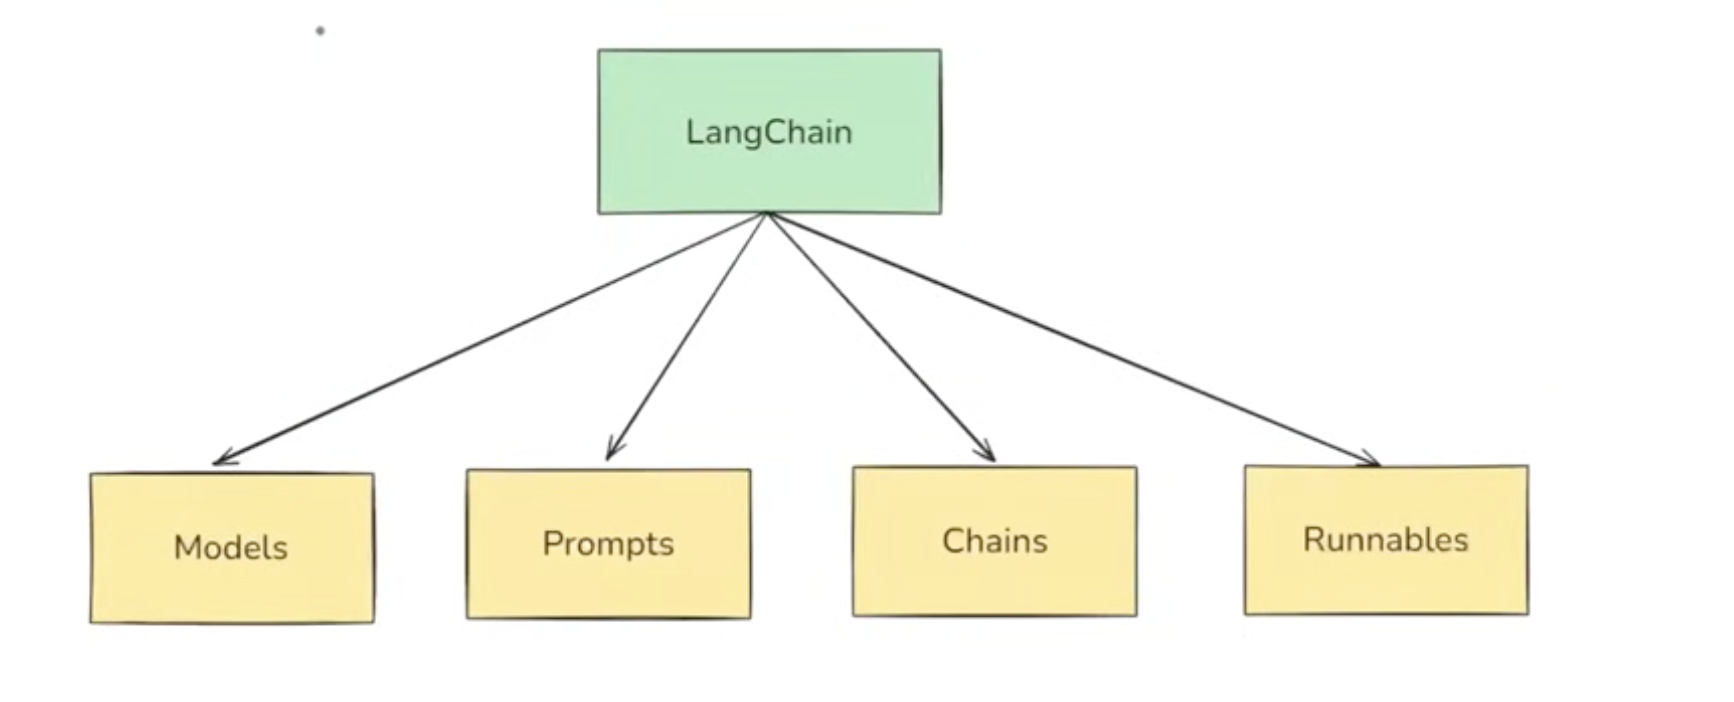

## The biggest use case of GenAI: Chatbots

One of the most common applications of Generative AI is a chatbot. For example, you open a chatbot, type: "Explain what a transformer is."

The basic flow is: User → Chatbot → LLM → Response

The LLM has learned patterns and information from its training data, so it generates an answer.

For example:

In [ ]:
# User: "What is a transformer?"

#               ↓

#           LLM/ChatGPT

#               ↓

# "Transformer is a neural network architecture
# based on the attention mechanism..."

***Important Point:*** An LLM primarily answers using the knowledge and patterns it learned during training, plus any information explicitly provided to it at inference time.

## But LLMs have a major limitation

An LLM does not automatically know everything about the world.

Eg 1- Suppose a model was trained on data available until some point in time. Now you ask: "What happened in the stock market 10 minutes ago? "The model may not know. Why? Because that information may have happened after its training data was collected.

Eg 2- "What emails did I receive in my company mailbox today?" The LLM doesn't automatically have access to your mailbox.

Eg 3- "What is the internal leave policy of my company?" If your company's internal documentation wasn't part of the model's accessible knowledge, it won't know the answer.

In [1]:
#                  LLM
#                   |
#         ---------------------
#         |                   |
#    Knows information    Doesn't know
#    from its knowledge   your private/
#    and context          latest information/ current affairs


# This is where RAG becomes useful.

## RAG (Retrieval Augmented Generation)

Retrieval : Find relevant information from an external knowledge source.

Augmented : Add that retrieved information to the LLM's input/context.

Generation: The LLM uses that information to generate the final answer.

RAG combines Information Retrieval + Language Generation.

RAG (Retrieval-Augmented Generation) is a technique in which relevant information is retrieved from an external knowledge source and provided as context to an LLM, which then generates a grounded response based on that information.

Instead of expecting the LLM to already know your information, you give your application access to an external knowledge base.

External knowledge base could be:

- Company Documents: HR Policy.pdf, Leave Policy.pdf, Insurance policy.pdf, Employee Handbook.pdf

- Technical Documentation: API documentation, Product documentation, Internal Wiki, Engineering Documentation

- Personal Documents: My Notes, My Resume, Research paper, College notes, Books

- Company Database: Customer database, product Database, sales Database, Employee Database

- Emails: Company Gmail i.e Email knowledge base

the RAG system retrieves it when needed.

In [ ]:
# RAG
# │
# ├── 1. Retrieval:The system searches the external knowledge base and finds info relevant to the user's Q
# │
# └── 2. Generation: LLM takes user Q + Retrieved info and generates a natural lang response


Retrieval-Augmented Generation = retrieve external information + provide it to the LLM + generate an answer using that information.

## Normal LLM vs RAG

This distinction is extremely important.

Without RAG: User -> Question -> LLM -> Answer

The LLM mainly relies on its learned knowledge and whatever context you provide.

In [ ]:
# With RAG:

#                  ┌───────────────┐
#                  │ Knowledge Base│
#                  │ PDFs          │
#                  │ Database      │
#                  │ Documents     │
#                  │ Emails        │
#                  └───────┬───────┘
#                          │
#                          ↓
# User → Question → Retriever
#                          │
#                          ↓
#                   Relevant Context
#                          │
#                          ↓
#                         LLM
#                          │
#                          ↓
#                        Answer

RAG is NOT the same as training the LLM nThis is a very important distinction.

Suppose you have: 1000 company PDFs

You might think: "I should train the LLM on these PDFs."

Usually, you don't need to do that just to make the information available.

With RAG: Company PDFs -> Knowledge Base -> Retriever -> Relevant info -> LLM

The LLM doesn't have to learn the documents permanently. Instead, the documents are retrieved at query time.

This is why RAG is often much more practical for frequently changing information.

In [ ]:
# Your notes use current affairs as an example.

# Suppose you ask:

# "What happened in the Indian stock market today?"

# A static LLM may not know today's events.

# A RAG-like system can retrieve recent information from an external source:

# User Question
#      ↓
# Retrieve latest information
#      ↓
# News / Database / Web
#      ↓
# Relevant information
#      ↓
# LLM
#      ↓
# Answer

## Benefits of using a RAG:

## 1. Use of up-to-date info:

Suppose your knowledge base contains:

- Latest company policies
- Latest product information
- Latest documentation
- Latest database records

The application can retrieve the latest relevant information.

Therefore, you don't necessarily have to retrain the LLM every time a document changes

## 2. Better Privacy:

Suppose a company has internal documents:

- Internal financial reports
- Employee policies
- Engineering documents
- Customer information

You may not want to train a public LLM on all this information. With RAG, the application can keep the documents in a controlled knowledge system and retrieve only the relevant information when needed.

However, one important correction: RAG does not automatically guarantee privacy. Privacy depends on how the entire system is designed—access controls, permissions, encryption, data handling, the model provider, logging, etc. So your note "better privacy" should really be understood as:

RAG can make it easier to keep private knowledge outside the model's permanent parameters and control access to that knowledge.

## 3. No limit of document size:

It does not mean: "I can give RAG a 10-million-page document and the LLM can read everything simultaneously." That's not how RAG works. Instead, RAG can handle large collections of documents by breaking them into smaller pieces.

For example: 1000 PDFs -> Split into chunks -> 100,000 chunks -> Convert chunks into embeddings -> Store in vector database

When the user asks a question:

Question -> Search millions of chunks -> Find top relevant chunks -> Send only those chunks to LLM
-> Answer

So the important advantage is: The entire document collection does not need to fit into the LLM's context window at once.

There are still practical limits involving storage, retrieval quality, chunking, context window, latency, and cost.

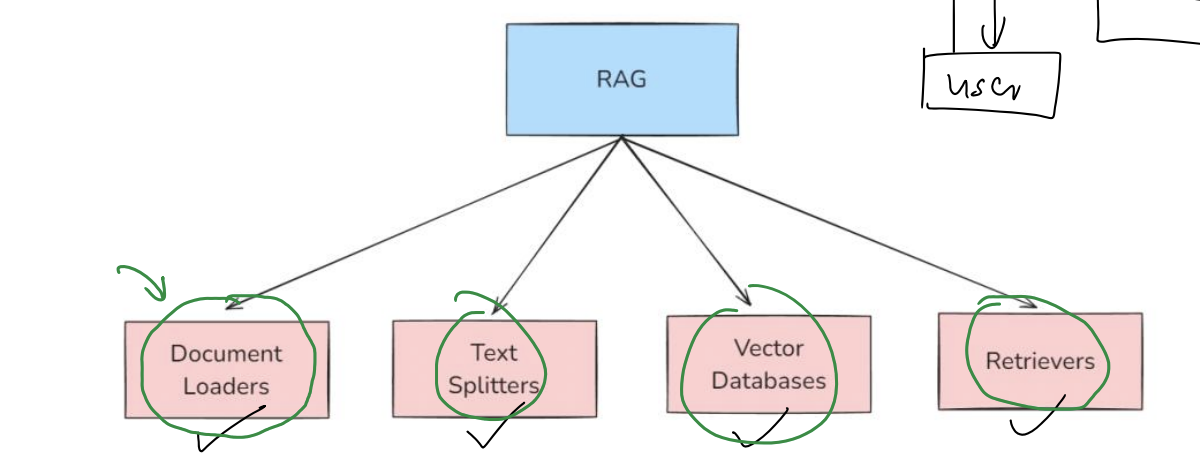

In [ ]:
#                                 RAG PIPELINE
# Different Data Sources
#            │
#            ↓
# ┌─────────────────────┐
# │  Document Loaders   │
# └──────────┬──────────┘
#            ↓
#       Document objects
#            ↓
# ┌─────────────────────┐
# │   Text Splitters    │
# └──────────┬──────────┘
#            ↓
#         Chunks
#            ↓
# ┌─────────────────────┐
# │     Embeddings      │
# └──────────┬──────────┘
#            ↓
#         Vectors
#            ↓
# ┌─────────────────────┐
# │  Vector Database    │
# └──────────┬──────────┘
#            ↓
# ┌─────────────────────┐
# │     Retriever       │
# └──────────┬──────────┘
#            ↓
#     Relevant Chunks
#            ↓
#           LLM
#            ↓
#         Answer

## Document Loader

The key idea is that data can come from many different places, but before RAG can process that data, we want to convert it into a common format.

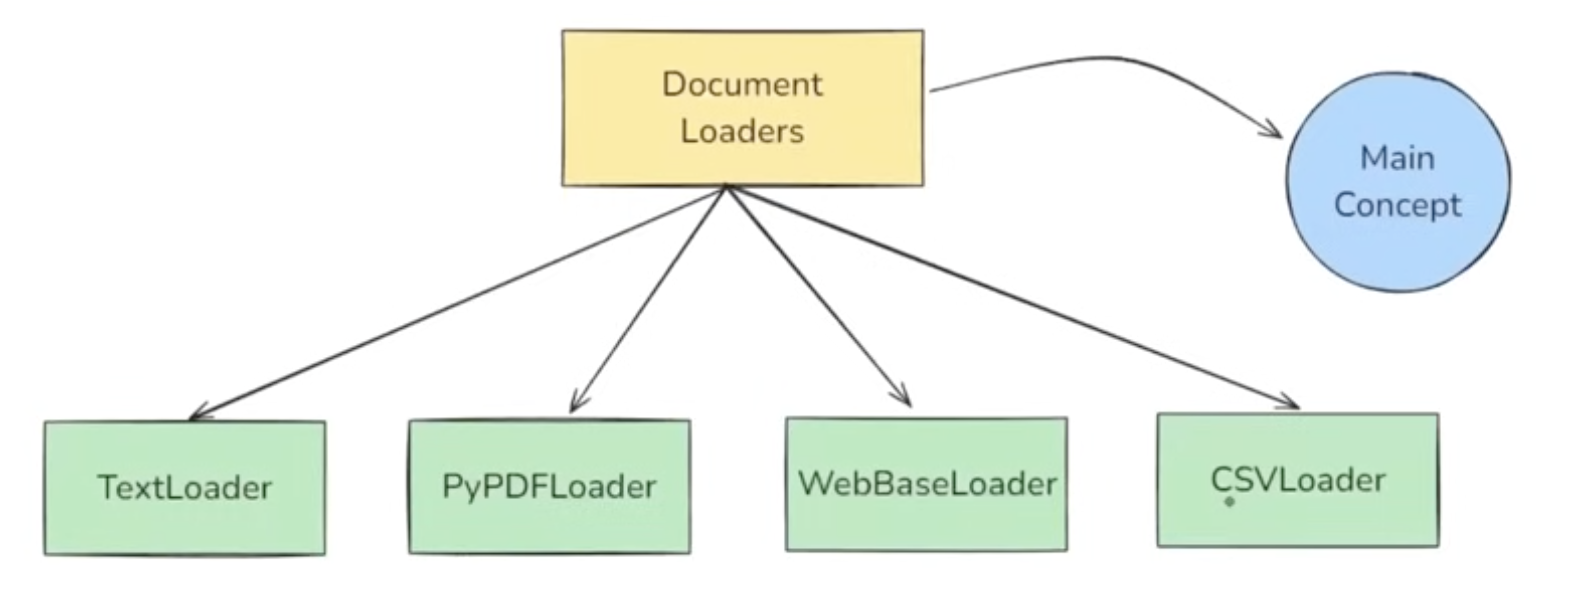

In Langchain, there are 100s of different kinds of document loaders. these are 4 most useful loaders

Earlier we saw the basic RAG pipeline:

User Question -> Retriever -> Relevant Documents -> LLM 

But where do those documents come from?

They can come from:

- PDF
- TXT
- Website
- CSV
- Database
- Cloud Storage
- Word file etc.

So before retrieval can happen, we need to bring all this data into our RAG system. That's where Document Loaders come in.

Document loaders are components in langchain used to load data from various sources into a standardized format (usually as Document objects), which can be used for chunking, embedding, retrieval and generation.

A Document Loader is a component that reads data from a particular source and converts it into a standard format that LangChain can work with.

## Document object

Has two attributes: page_content and metadata

In [ ]:
Document(page_content='The actual text content', metadata={"source":'filename.pdf', ...})

Metadata: The exact metadata depends on the loader/source.

- source = rag_notes.pdf
- page = 5
- author = ABC
- department = Engineering
- document_type = PDF

So metadata is extremely useful for:

- source tracking
- citations
- filtering
- debugging
- document identification
- page references
- access control in some architectures

To Use any doc loader, use langchain_community package

## TextLoader

TextLoader is a simple and commonly used document laoder in langchain that reads plan text files (.txt) and converts them into LangChain Document objects

Limitation: Works only with .txt file

Use Case: Ideal for loading chat logs, transcripts, scraped text, code snippets, or any plain text into a langchain pipeline

In [8]:
from langchain_community.document_loaders import TextLoader

loader=TextLoader(file_path='/Users/priyanshugupta/Desktop/Generative AI/pokemon.txt',encoding='utf-8')

## loader.load() will load the document into your memory

docs= loader.load()

print(docs)
print(type(docs))

[Document(metadata={'source': '/Users/priyanshugupta/Desktop/Generative AI/pokemon.txt'}, page_content='What is Pokémon?\nPokémon (short for Pocket Monsters) is a globally renowned media franchise centered on fictional creatures with unique powers, abilities, and designs. Created by Satoshi Tajiri and Ken Sugimori, the franchise debuted in 1996 with the release of the Pokémon Red and Blue video games for the Nintendo Game Boy.\n\nToday, Pokémon spans video games, trading card games (TCG), animated television series, movies, merchandise, and competitive esports, making it one of the highest-grossing media franchises of all time.\n\nCore Concept and Gameplay\nThe central premise of the Pokémon universe revolves around humans—known as Pokémon Trainers—who catch, train, and battle creatures called Pokémon.\n\nThe Goal: Trainers typically aim to catch a wide variety of species to complete the Pokédex (an electronic encyclopedia) and train a team of Pokémon to battle other trainers, ultimate

Document loader loads documents as a list of documents 

In [10]:
print(len(docs)) ## currently there is only 1 document

1


In [11]:
print(docs[0])

page_content='What is Pokémon?
Pokémon (short for Pocket Monsters) is a globally renowned media franchise centered on fictional creatures with unique powers, abilities, and designs. Created by Satoshi Tajiri and Ken Sugimori, the franchise debuted in 1996 with the release of the Pokémon Red and Blue video games for the Nintendo Game Boy.

Today, Pokémon spans video games, trading card games (TCG), animated television series, movies, merchandise, and competitive esports, making it one of the highest-grossing media franchises of all time.

Core Concept and Gameplay
The central premise of the Pokémon universe revolves around humans—known as Pokémon Trainers—who catch, train, and battle creatures called Pokémon.

The Goal: Trainers typically aim to catch a wide variety of species to complete the Pokédex (an electronic encyclopedia) and train a team of Pokémon to battle other trainers, ultimately striving to become a Pokémon Champion.

Turn-Based Combat: Battles are strategic and turn-based

In [ ]:
type(docs[0]) ## it is a document type 

langchain_core.documents.base.Document

In [13]:
print(docs[0].page_content)

What is Pokémon?
Pokémon (short for Pocket Monsters) is a globally renowned media franchise centered on fictional creatures with unique powers, abilities, and designs. Created by Satoshi Tajiri and Ken Sugimori, the franchise debuted in 1996 with the release of the Pokémon Red and Blue video games for the Nintendo Game Boy.

Today, Pokémon spans video games, trading card games (TCG), animated television series, movies, merchandise, and competitive esports, making it one of the highest-grossing media franchises of all time.

Core Concept and Gameplay
The central premise of the Pokémon universe revolves around humans—known as Pokémon Trainers—who catch, train, and battle creatures called Pokémon.

The Goal: Trainers typically aim to catch a wide variety of species to complete the Pokédex (an electronic encyclopedia) and train a team of Pokémon to battle other trainers, ultimately striving to become a Pokémon Champion.

Turn-Based Combat: Battles are strategic and turn-based. Pokémon use 

In [14]:
print(docs[0].metadata)

{'source': '/Users/priyanshugupta/Desktop/Generative AI/pokemon.txt'}


In [15]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv

load_dotenv()

True

In [18]:
llm=HuggingFaceEndpoint(
    task='text-generation',
    repo_id='Qwen/Qwen3-4B-Instruct-2507'
)

model=ChatHuggingFace(llm=llm)

parser=StrOutputParser()

prompt=PromptTemplate(
    template= " Write a summary for the following description- \n {text}",
    input_variables=['text']
)

loader=TextLoader('/Users/priyanshugupta/Desktop/Generative AI/pokemon.txt',encoding='utf-8')
docs=loader.load()

chain = prompt | model | parser

result=chain.invoke({'text':docs[0].page_content})
print(result)

**Summary of Pokémon:**

Pokémon, short for Pocket Monsters, is a global media franchise created by Satoshi Tajiri and Ken Sugimori, first launched in 1996 with the Nintendo Game Boy games *Red* and *Blue*. At its core, the franchise revolves around Pokémon Trainers who catch, train, and battle fictional creatures known as Pokémon. The goal is to complete the Pokédex, build a strong team, and become a Pokémon Champion through strategic turn-based battles.

Key gameplay elements include the **Type Advantage System**, where different elemental types (such as Fire, Water, Grass, Electric, and Psychic) have strengths and weaknesses against one another, and **Pokémon Evolution**, where creatures transform into stronger forms based on level, items, or friendship. The universe features 18 elemental types and includes rare, powerful **Legendary and Mythical Pokémon** that play vital roles in its lore.

Spanning video games (organized by generations), trading card games (TCG), animated series (

## PyPDFLoader

a type of Document loader in langchain used to load content from PDF files and convert each page into a document object

It uses PyPDF library . Use PyPDF Loader when pdf consists mostly textual data

In [ ]:
[
    Document(page_content='....',metadata={'page':0,'source':'file.pdf'}),
    Document(page_content='....',metadata={'page':1,'source':'file.pdf'}),
    ....
]

Limitations: Not greate with scanned pdfs or complex layouts. Not great with docs which has text in image form

25 Pages pdf -> PyPDFLoader -> creates 25 document objects

In [21]:
from langchain_community.document_loaders import PyPDFLoader

loader=PyPDFLoader(file_path='/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf')
docs=loader.load()


In [26]:
docs

[Document(metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2024-07-07T12:07:05+00:00', 'title': 'Sample 5-Page PDF A4 Size | Sample-Files.com', 'moddate': '2024-07-07T12:07:04+00:00', 'keywords': 'DAGKRGfiZEo,BAEVm-WErFA', 'author': 'Jericho', 'source': '/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf', 'total_pages': 5, 'page': 0, 'page_label': '1'}, page_content='Innovative Tech\nSolutions, Inc.\nProduct Launch Report:\nSmartHome Hub\nPrepared by:\nAlex Johnson\nsample-files.com\n+1-555-123-4567'),
 Document(metadata={'producer': 'Canva', 'creator': 'Canva', 'creationdate': '2024-07-07T12:07:05+00:00', 'title': 'Sample 5-Page PDF A4 Size | Sample-Files.com', 'moddate': '2024-07-07T12:07:04+00:00', 'keywords': 'DAGKRGfiZEo,BAEVm-WErFA', 'author': 'Jericho', 'source': '/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf', 'total_pages': 5, 'page': 1, 'page_label': '2'}, page_content='Introduction\nThis report outlines t

In [23]:
len(docs)

5

In [24]:
docs[0].page_content

'Innovative Tech\nSolutions, Inc.\nProduct Launch Report:\nSmartHome Hub\nPrepared by:\nAlex Johnson\nsample-files.com\n+1-555-123-4567'

In [25]:
docs[0].metadata

{'producer': 'Canva',
 'creator': 'Canva',
 'creationdate': '2024-07-07T12:07:05+00:00',
 'title': 'Sample 5-Page PDF A4 Size | Sample-Files.com',
 'moddate': '2024-07-07T12:07:04+00:00',
 'keywords': 'DAGKRGfiZEo,BAEVm-WErFA',
 'author': 'Jericho',
 'source': '/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf',
 'total_pages': 5,
 'page': 0,
 'page_label': '1'}

In [27]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv

load_dotenv()

True

In [28]:
llm=HuggingFaceEndpoint(
    task='text-generation',
    repo_id='Qwen/Qwen3-4B-Instruct-2507'
)

model=ChatHuggingFace(llm=llm)

parser=StrOutputParser()

prompt=PromptTemplate(
    template= " Write a summary for the following description- \n {text}",
    input_variables=['text']
)

loader=PyPDFLoader(file_path='/Users/priyanshugupta/Desktop/Generative AI/sample-5-page-pdf-a4-size.pdf')
docs=loader.load()

chain = prompt | model | parser

result=chain.invoke({'text':docs[0].page_content})
print(result)

**Summary:**

Innovative Tech Solutions, Inc. presents the *SmartHome Hub* product launch report prepared by Alex Johnson. The SmartHome Hub is a next-generation central device designed to integrate and control all smart home devices—such as lighting, security, thermostats, and appliances—through a single, user-friendly interface. Featuring advanced AI-driven automation, voice compatibility, and seamless cloud connectivity, the hub offers enhanced convenience, energy efficiency, and remote access. This report outlines the product features, target market, launch strategy, and initial feedback, highlighting its potential to revolutionize home automation. Contact: sample-files.com | Phone: +1-555-123-4567.


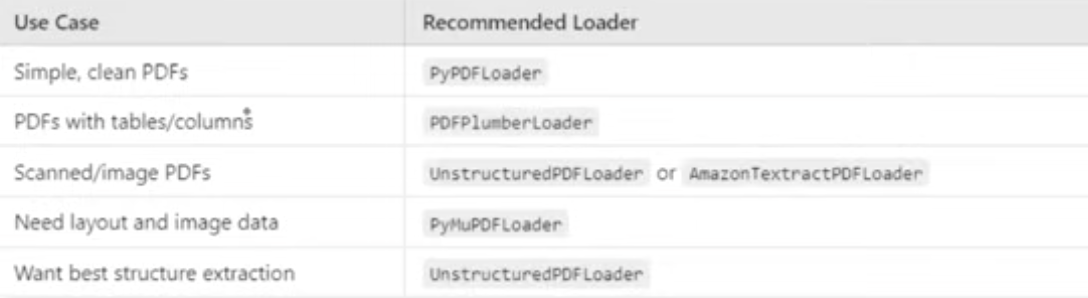

In [1]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv

load_dotenv()

True

In [34]:
%pip install "unstructured[pdf]"

  Using cached scipy-1.18.0-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.2/542.2 kB 2.0 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 2.1 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 959.6/959.6 kB 3.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 3.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 3.0 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 2.5 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.5/565.5 kB 3.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 3.0 MB/s  0:00:06m0:00:0100:01
Using cached scipy-1.18.0-cp313-cp313-macosx_14_0_arm64.whl (20.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.9 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    U

In [ ]:
from langchain_community.document_loaders import UnstructuredPDFLoader
llm=HuggingFaceEndpoint(
    task='text-generation',
    repo_id='Qwen/Qwen3-4B-Instruct-2507'
)

model=ChatHuggingFace(llm=llm)

parser=StrOutputParser()

loader=UnstructuredPDFLoader(file_path='/Users/priyanshugupta/Desktop/Generative AI/image-doc.pdf')
docs=loader.load()


No languages specified, defaulting to English.


In [10]:
print(docs[0].page_content[:1000])

Image-Heavy PDF

Prepared By: Sample Team

Website: sample-files.com

Nature Landscape

A beautiful landscape showcasing the wonders of nature.

This sample PDF file is provided by Sample-Files.com. Visit us for more sample files and resource.

City Skyline

A high-resolution image of a bustling city skyline at night.

This sample PDF file is provided by Sample-Files.com. Visit us for more sample files and resource.

Wildlife Photography

An up-close capture of wildlife in their natural habitat.

This sample PDF file is provided by Sample-Files.com. Visit us for more sample files and resource.

Space Exploration

An artistic representation of space exploration and galaxies.

This sample PDF file is provided by Sample-Files.com. Visit us for more sample files and resource.

Underwater World

A breathtaking view of marine life deep beneath the ocean.

This sample PDF file is provided by Sample-Files.com. Visit us for more sample files and resource.


In [11]:

prompt=PromptTemplate(
    template= " Write a summary for the following  \n {text}",
    input_variables=['text']
)
chain = prompt | model | parser

result=chain.invoke({'text':docs[0].page_content})
print(result)

**Summary:**

This image-heavy PDF, prepared by the Sample Team and available at sample-files.com, features a collection of visually stunning nature and urban imagery. It includes five distinct image themes:  
- *Nature Landscape*: A beautiful portrayal of natural scenery and environmental beauty.  
- *City Skyline*: A high-resolution nighttime view of a vibrant, bustling city.  
- *Wildlife Photography*: Close-up shots capturing animals in their natural habitats.  
- *Space Exploration*: An artistic depiction of galaxies and space missions.  
- *Underwater World*: A mesmerizing glimpse into marine life beneath the ocean's surface.  

Each image is presented in high quality and accompanied by a brief description. The PDF serves as a sample resource for users interested in visual content and is part of a broader collection available on sample-files.com.


## DirectoryLoader

DirectoryLoader is a Document Loader that lets you load multiple documents from a directory (folder) of files

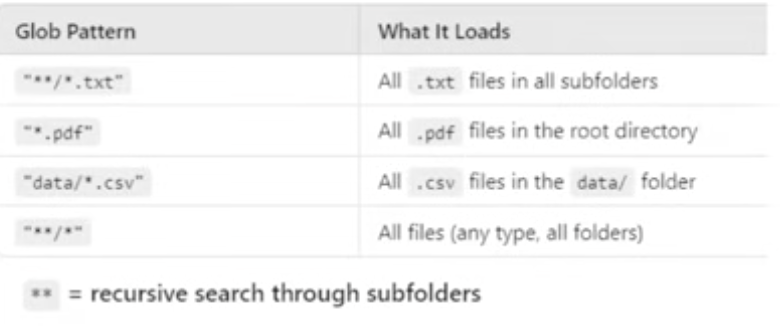

In [1]:
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader

loader=DirectoryLoader(
    path='/Users/priyanshugupta/Desktop/Generative AI/Books',
    glob='*.pdf' ,## by glob parameter you decide which docs to load 
    loader_cls=PyPDFLoader
)

docs=loader.load()
print(len(docs))

1934


In [2]:
print(docs[0].metadata)
print(docs[0].page_content)

{'producer': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creator': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creationdate': '2021-05-28T18:47:48+00:00', 'author': 'Amit Kumar Das & Saikat Dutt & Subramanian Chandramouli', 'moddate': '2021-05-28T18:47:48+00:00', 'title': 'Machine Learning', 'source': '/Users/priyanshugupta/Desktop/Generative AI/Books/Machine Learning ( etc.) (z-lib.org).pdf', 'total_pages': 741, 'page': 0, 'page_label': '1'}



In [3]:
print(docs[392].page_content)
print(docs[392].metadata)

FIG. 8.11 Extended version of the regression graph
FIG. 8.12 Zoom-in regression line
Slope measures the estimated change in the average value of
Y as a result of a one-unit change in X. Here, slope = 1.89 tells
us that the average value of the external examination marks
{'producer': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creator': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creationdate': '2021-05-28T18:47:48+00:00', 'author': 'Amit Kumar Das & Saikat Dutt & Subramanian Chandramouli', 'moddate': '2021-05-28T18:47:48+00:00', 'title': 'Machine Learning', 'source': '/Users/priyanshugupta/Desktop/Generative AI/Books/Machine Learning ( etc.) (z-lib.org).pdf', 'total_pages': 741, 'page': 392, 'page_label': '393'}


Problem1:
 
if loading three pdfs take so much time, then imagine what will happen if we load 100s of such documents


Problem2:

You load all these pdfs into RAM so that you can perform operations on it but it might not be possible to load 1000s of documents

Solution of both problems are given by langchain which is lazy loading

## load() vs lazy_load() = Load everything now vs. load documents one at a time when needed.

## load() — Eager Loading

Eager Loading (loads everything at once): docs = loader.load()

LangChain loads all the documents immediately and returns them as a Python list.

Conceptually: load() returns list of document objects

In [ ]:
# PDF
#  ↓
# loader.load()
#  ↓
# ┌───────────────┐
# │ Document 1    │
# │ Document 2    │
# │ Document 3    │
# │ Document 4    │
# │ ...           │
# │ Document 3000 │
# └───────────────┘
#        ↓
#      memory

# Read all the available documents now and give me the complete list


It is called Eager loading because it doesn't wait. It says give me everything now

Pros: Best when the number of documents is small

## lazy_load (Lazy Loading)

Lazy Loading (loads on demand).

docs = loader.lazy_load() returns a generator 

Documents are produced one at a time rather than all being loaded into a list immediately.

In [ ]:
    #          loader.lazy_load()
    #                 ↓
    #             Generator
    #                 ↓
    #     ┌───────────┼───────────┐
    #     ↓           ↓           ↓
    # Document 1  Document 2  Document 3
    #     ↓           ↓           ↓
    #  process     process     process

## What is generator ?

It is a python concept, A generator produces values one at a time

In [ ]:
def numbers():
    for i in range(5):
        yield i

gen=numbers()
gen

<generator object numbers at 0x34b6c2380>

doesn't immediately create a list: [0, 1, 2, 3, 4]

Instead, it gives you a generator. You can consume it:

In [8]:
for x in gen:
    print(x)

0
1
2
3
4


The values are produced as you iterate.

That's the basic idea behind lazy_load().

***lazy_load() returns a generator of Documents***

Documents get deleted from memory once they are loaded then next doc is loaded into memory then deleted (one by one)

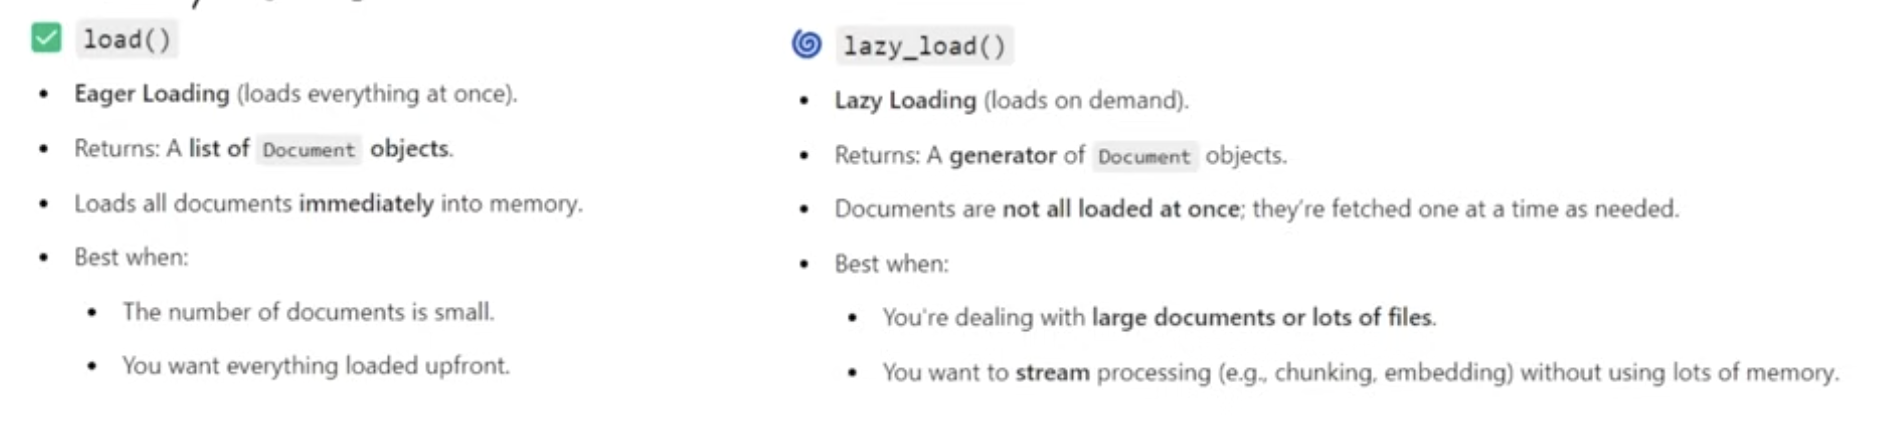

In [9]:
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
import time
loader=DirectoryLoader(
    path='/Users/priyanshugupta/Desktop/Generative AI/Books',
    glob='*.pdf' ,## by glob parameter you decide which docs to load 
    loader_cls=PyPDFLoader
)

docs=loader.load()

for document in docs:
    print(document.metadata)



{'producer': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creator': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creationdate': '2021-05-28T18:47:48+00:00', 'author': 'Amit Kumar Das & Saikat Dutt & Subramanian Chandramouli', 'moddate': '2021-05-28T18:47:48+00:00', 'title': 'Machine Learning', 'source': '/Users/priyanshugupta/Desktop/Generative AI/Books/Machine Learning ( etc.) (z-lib.org).pdf', 'total_pages': 741, 'page': 0, 'page_label': '1'}
{'producer': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creator': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creationdate': '2021-05-28T18:47:48+00:00', 'author': 'Amit Kumar Das & Saikat Dutt & Subramanian Chandramouli', 'moddate': '2021-05-28T18:47:48+00:00', 'title': 'Machine Learning', 'source': '/Users/priyanshugupta/Desktop/Generative AI/Books/Machine Learning ( etc.) (z-lib.org).pdf', 'total_pages': 741, 'page': 1, 'page_label': '2'}
{'producer': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creator': 'calibre (4.99.4) [

In [10]:
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
import time
loader=DirectoryLoader(
    path='/Users/priyanshugupta/Desktop/Generative AI/Books',
    glob='*.pdf' ,## by glob parameter you decide which docs to load 
    loader_cls=PyPDFLoader
)

docs=loader.lazy_load()

for document in docs:
    print(document.metadata)



{'producer': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creator': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creationdate': '2021-05-28T18:47:48+00:00', 'author': 'Amit Kumar Das & Saikat Dutt & Subramanian Chandramouli', 'moddate': '2021-05-28T18:47:48+00:00', 'title': 'Machine Learning', 'source': '/Users/priyanshugupta/Desktop/Generative AI/Books/Machine Learning ( etc.) (z-lib.org).pdf', 'total_pages': 741, 'page': 0, 'page_label': '1'}
{'producer': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creator': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creationdate': '2021-05-28T18:47:48+00:00', 'author': 'Amit Kumar Das & Saikat Dutt & Subramanian Chandramouli', 'moddate': '2021-05-28T18:47:48+00:00', 'title': 'Machine Learning', 'source': '/Users/priyanshugupta/Desktop/Generative AI/Books/Machine Learning ( etc.) (z-lib.org).pdf', 'total_pages': 741, 'page': 1, 'page_label': '2'}
{'producer': 'calibre (4.99.4) [http://calibre-ebook.com]', 'creator': 'calibre (4.99.4) [

## WebBaseLoader

WebBaseLoader is a document loader in langchain used to load and extract text from web pages (URLs)

It uses BeautifulSoup under the hood to parse HTML and extract visible text 


When to use ?

- For blogs, news articles, or public websites where the content is primarily text based and static.

Limitations:

- Loads only static content ( What is in the HTML, not what loads after the page renders)
- Doesn't handle JavaScript heavy pages well (Use SeleniumURLLoader for that)

In [14]:
from langchain_community.document_loaders import WebBaseLoader
url='https://en.wikipedia.org/wiki/Anime'
loader=WebBaseLoader(url)

docs=loader.load()

print(docs)

[Document(metadata={'source': 'https://en.wikipedia.org/wiki/Anime', 'title': 'Anime - Wikipedia', 'language': 'en'}, page_content='\n\n\n\nAnime - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nEtymology\n\n\n\n\n\n\n\n\n2\nHistory\n\n\n\n\nToggle History subsection\n\n\n\n\n\n2

In [15]:
print(docs[0].page_content)





Anime - Wikipedia





























Jump to content







Main menu





Main menu
move to sidebar
hide



		Navigation
	


Main pageContentsCurrent eventsRandom articleAbout WikipediaContact us





		Contribute
	


HelpLearn to editCommunity portalRecent changesUpload fileSpecial pages



















Search











Search






















Appearance
















Donate

Create account

Log in








Personal tools






Donate


Create account


Log in





























Contents
move to sidebar
hide




(Top)





1
Etymology








2
History




Toggle History subsection





2.1
Precursors








2.2
Pioneers








2.3
Modern era










3
Attributes




Toggle Attributes subsection





3.1
Technique








3.2
Characters








3.3
Music








3.4
Genres








3.5
Formats










4
Industry




Toggle Industry subsection





4.1
Markets








4.2
Awards








4.3
Working conditions










5
Global popularity and cul

In [ ]:
## no of output you get in docs is only 1
len(docs)

## 1 URL -> 1 document object

1

In [17]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv

load_dotenv()

True

In [18]:
from langchain_community.document_loaders import WebBaseLoader
url='https://en.wikipedia.org/wiki/Anime'
loader=WebBaseLoader(url)

docs=loader.load()

llm=HuggingFaceEndpoint(
    task='text-generation',
    repo_id='Qwen/Qwen3-4B-Instruct-2507'
)

model=ChatHuggingFace(llm=llm)

parser=StrOutputParser()

prompt=PromptTemplate(
    template= " Answer the following question \n {question} from the following text -\n {text}",
    input_variables=['text','question']
)


chain = prompt | model | parser

result=chain.invoke({'text':docs[0].page_content, 'question':'What are the most popular anime '})
print(result)

Based on the provided text, the most popular anime are those that have achieved significant global recognition, high viewership, and major awards. The text explicitly mentions several titles that are highlighted as top contenders or achievements in terms of popularity and demand.

The most popular anime mentioned in the text are:

1.  **Demon Slayer: Kimetsu no Yaiba** - This is stated as the highest-grossing anime film (and one of the world's highest-grossing films of 2020), and it became the fastest-grossing film in Japanese cinema history, surpassing *Spirited Away*.
2.  **Attack on Titan** - This series won the "Most In-Demand TV Series in the World 2021" award and became the first non-English language series to earn the title of "World's Most In-Demand TV Show."
3.  **Jujutsu Kaisen** - This series is noted as being among the top 10 most discussed TV shows worldwide on Twitter in 2021 and, in 2024, broke the Guinness World Record for the "Most in-demand animated TV show."
4.  **Po

## CSVLoader

CSVLoader is a document loader used to load large CSV files into langchain Document Objects- one per row , by default

One row -> one document object

In [19]:
from langchain_community.document_loaders import CSVLoader

loader=CSVLoader(file_path='/Users/priyanshugupta/Desktop/Generative AI/pokemon.csv')
docs=loader.load()

docs

[Document(metadata={'source': '/Users/priyanshugupta/Desktop/Generative AI/pokemon.csv', 'row': 0}, page_content='#: 1\nName: Bulbasaur\nType 1: Grass\nType 2: Poison\nTotal: 318\nHP: 45\nAttack: 49\nDefense: 49\nSp. Atk: 65\nSp. Def: 65\nSpeed: 45\nGeneration: 1\nLegendary: False'),
 Document(metadata={'source': '/Users/priyanshugupta/Desktop/Generative AI/pokemon.csv', 'row': 1}, page_content='#: 2\nName: Ivysaur\nType 1: Grass\nType 2: Poison\nTotal: 405\nHP: 60\nAttack: 62\nDefense: 63\nSp. Atk: 80\nSp. Def: 80\nSpeed: 60\nGeneration: 1\nLegendary: False'),
 Document(metadata={'source': '/Users/priyanshugupta/Desktop/Generative AI/pokemon.csv', 'row': 2}, page_content='#: 3\nName: Venusaur\nType 1: Grass\nType 2: Poison\nTotal: 525\nHP: 80\nAttack: 82\nDefense: 83\nSp. Atk: 100\nSp. Def: 100\nSpeed: 80\nGeneration: 1\nLegendary: False'),
 Document(metadata={'source': '/Users/priyanshugupta/Desktop/Generative AI/pokemon.csv', 'row': 3}, page_content='#: 3\nName: VenusaurMega Venusau

In [20]:
docs[500].page_content

'#: 450\nName: Hippowdon\nType 1: Ground\nType 2: \nTotal: 525\nHP: 108\nAttack: 112\nDefense: 118\nSp. Atk: 68\nSp. Def: 72\nSpeed: 47\nGeneration: 4\nLegendary: False'

In [21]:
len(docs)

800

## Web pages

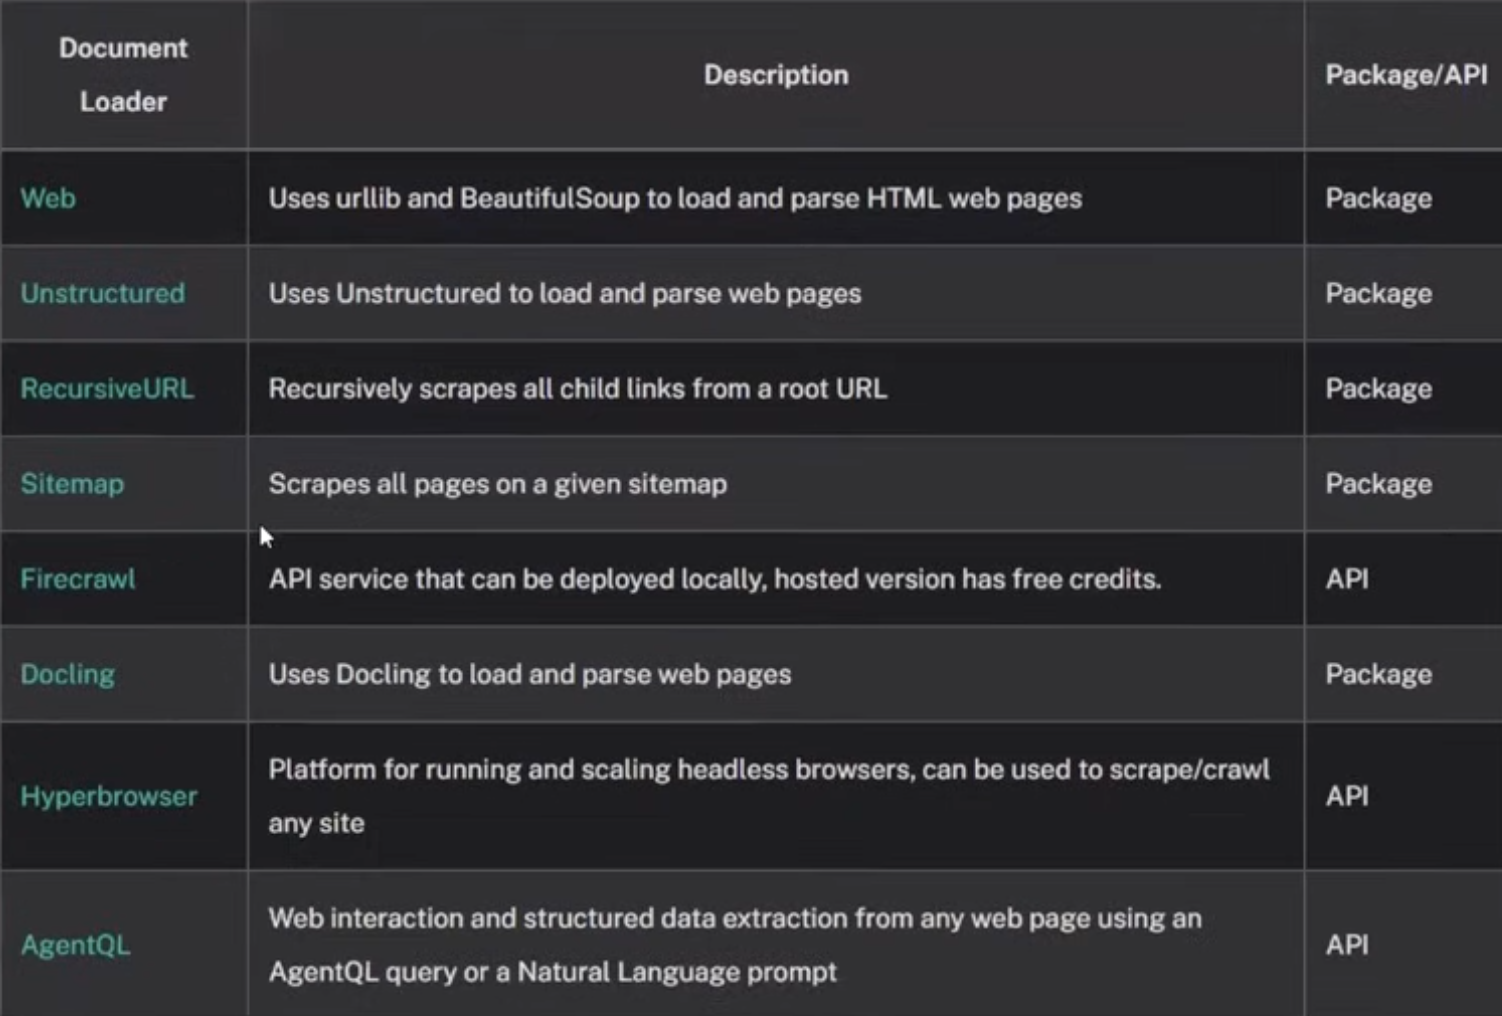

## Cloud services loader

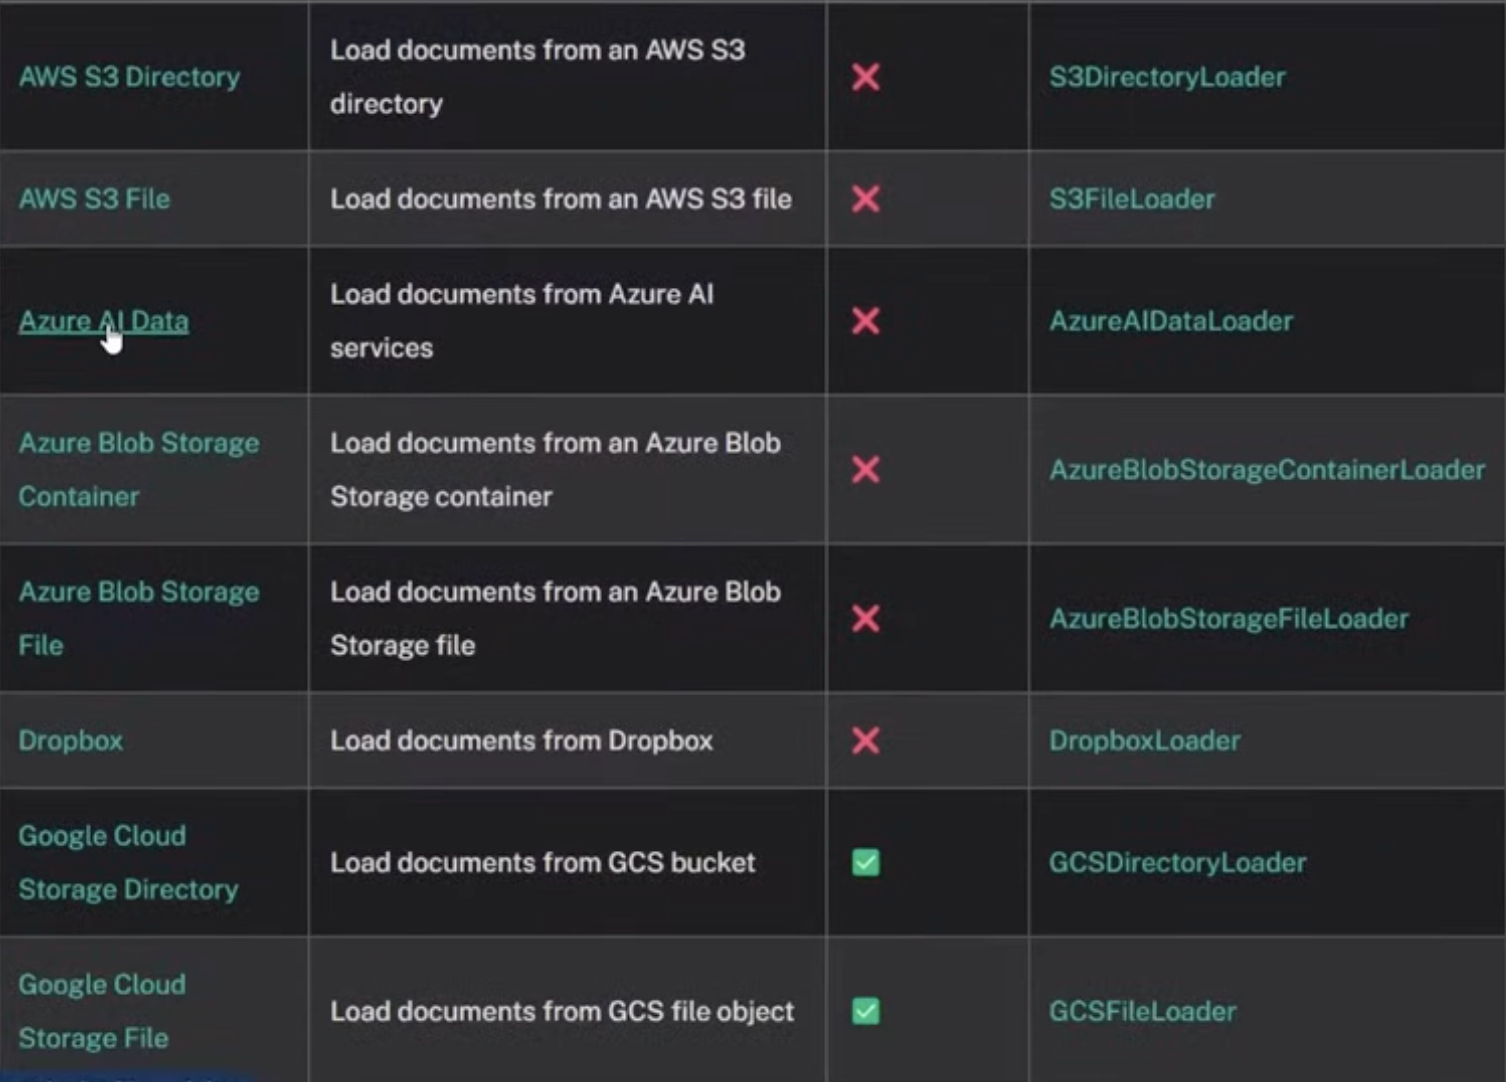

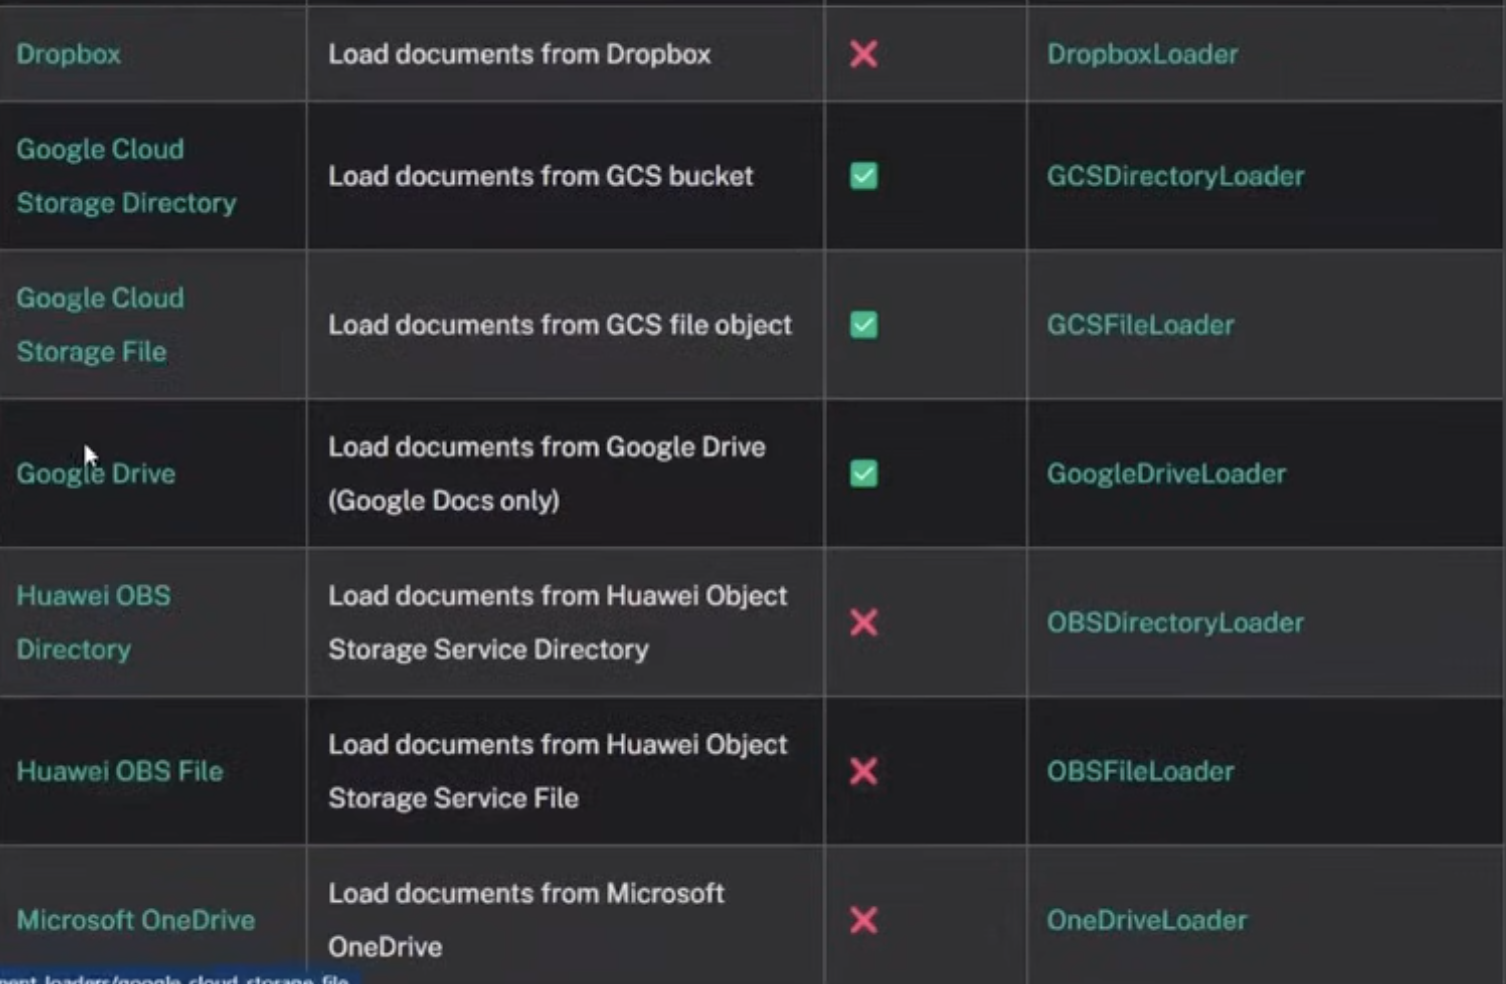

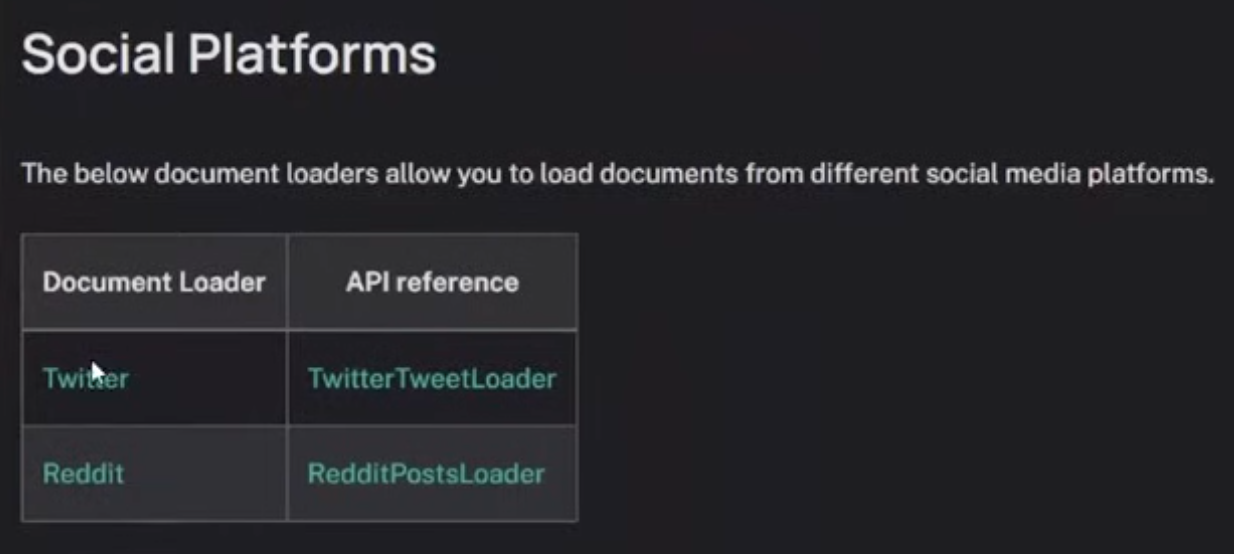

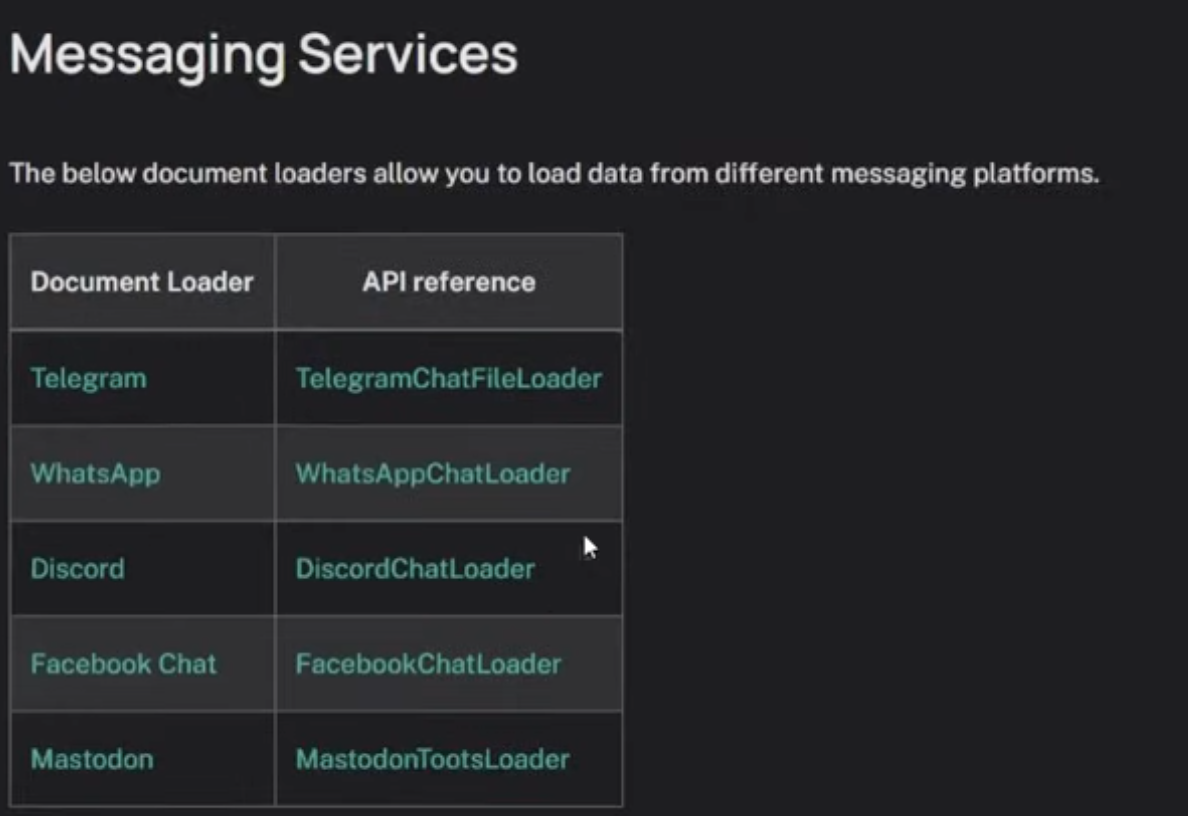

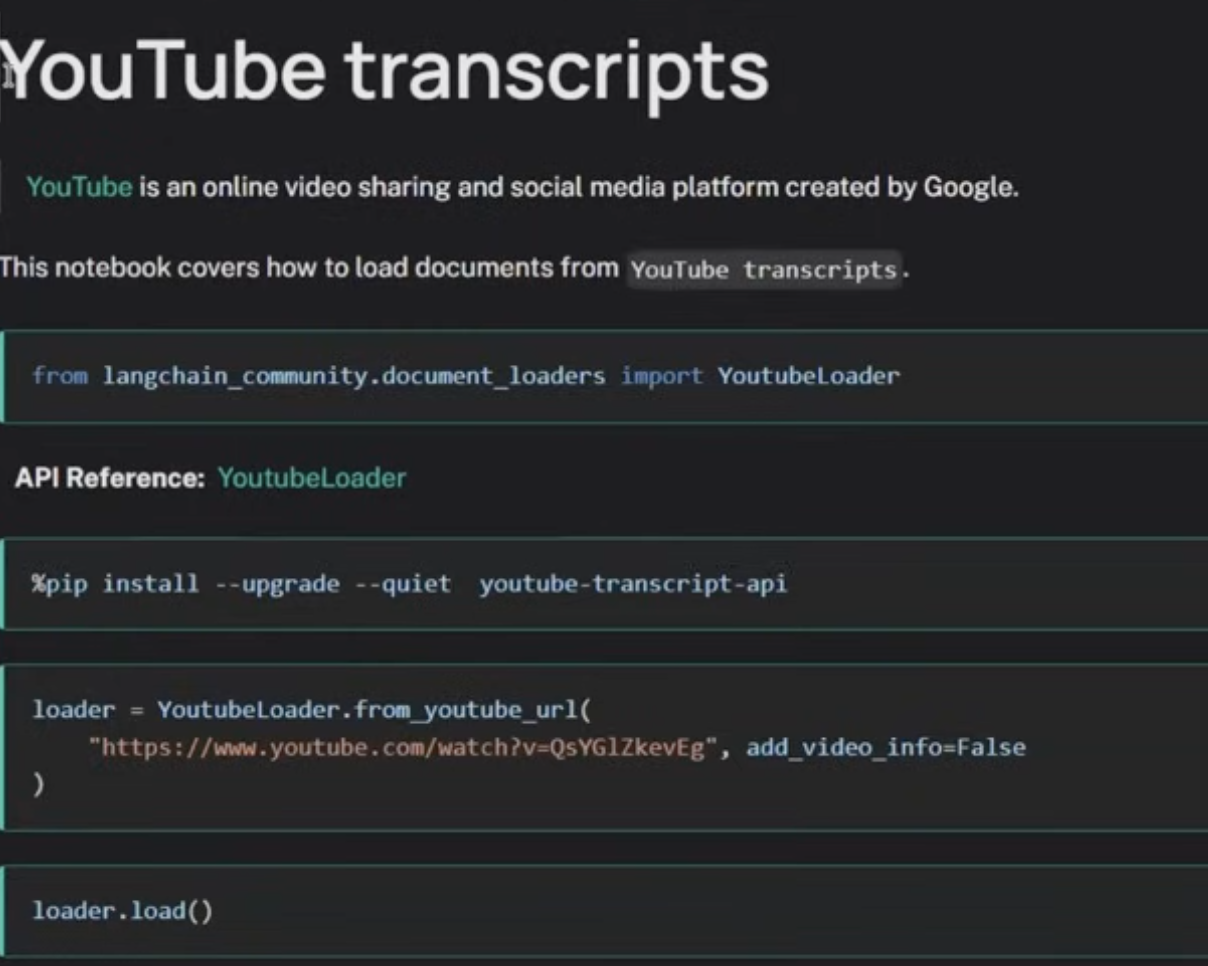

## Custom document Loaders

you define your load and lazy load function

You inherit your class from BaseLoader class

In [22]:
from typing import Iterator

from langchain_core.document_loaders import BaseLoader
from langchain_core.documents import Document


class CustomDocumentLoader(BaseLoader):
    """An example document loader that reads a file line by line."""

    def __init__(self, file_path: str) -> None:
        """Initialize the loader with a file path.

        Args:
            file_path: The path to the file to load.
        """
        self.file_path = file_path

    def lazy_load(self) -> Iterator[Document]:
        """A lazy loader that reads a file line by line.

        When you're implementing lazy load methods, you should use a
        generator to yield documents one by one.
        """

        with open(self.file_path, encoding="utf-8") as f:
            line_number = 0

            for line in f:
                yield Document(
                    page_content=line,
                    metadata={
                        "line_number": line_number,
                        "source": self.file_path,
                    },
                )

                line_number += 1

    # lazy_load is OPTIONAL.
    # If you leave out the implementation, a default implementation
    # which delegates to lazy_load will be used.